# Machin!!


In [188]:
import scanpy as sc
import os
import matplotlib.pyplot as plt

In [189]:
# Load as cells x genes (transpose because genes are rows in gut.tsv)
data = sc.read_text(os.getcwd() + "\\gut.tsv", delimiter="\t").T
data.var_names_make_unique()

In [190]:

n_cells_1 = data.n_obs
n_genes_1 = data.n_vars

In [191]:
#filters
sc.pp.filter_cells(data, min_genes=200) # filter low-quality cells
sc.pp.filter_genes(data, min_cells=100)  # filter rare genes

In [192]:
n_cells_2 = data.n_obs
n_genes_2 = data.n_vars
print(f"number of cells removed:{n_cells_1 - n_cells_2}")
print(f"number of genes removed:{n_genes_1 - n_genes_2}")

number of cells removed:0
number of genes removed:5618


In [193]:
sc.pp.calculate_qc_metrics(data, inplace=True)
n_cells_by_counts = data.var.n_cells_by_counts
mean_counts = data.var.mean_counts
total_counts = data.obs.total_counts

In [ ]:
print(n_cells_by_counts)

128up                   123
14-3-3epsilon          3064
14-3-3zeta             4622
18SrRNA-Psi:CR41602    1062
18w                     472
                       ... 
zf30C                   177
zfh1                    120
zfh2                    671
zip                    3531
zormin                 1479
Name: n_cells_by_counts, Length: 6312, dtype: int64


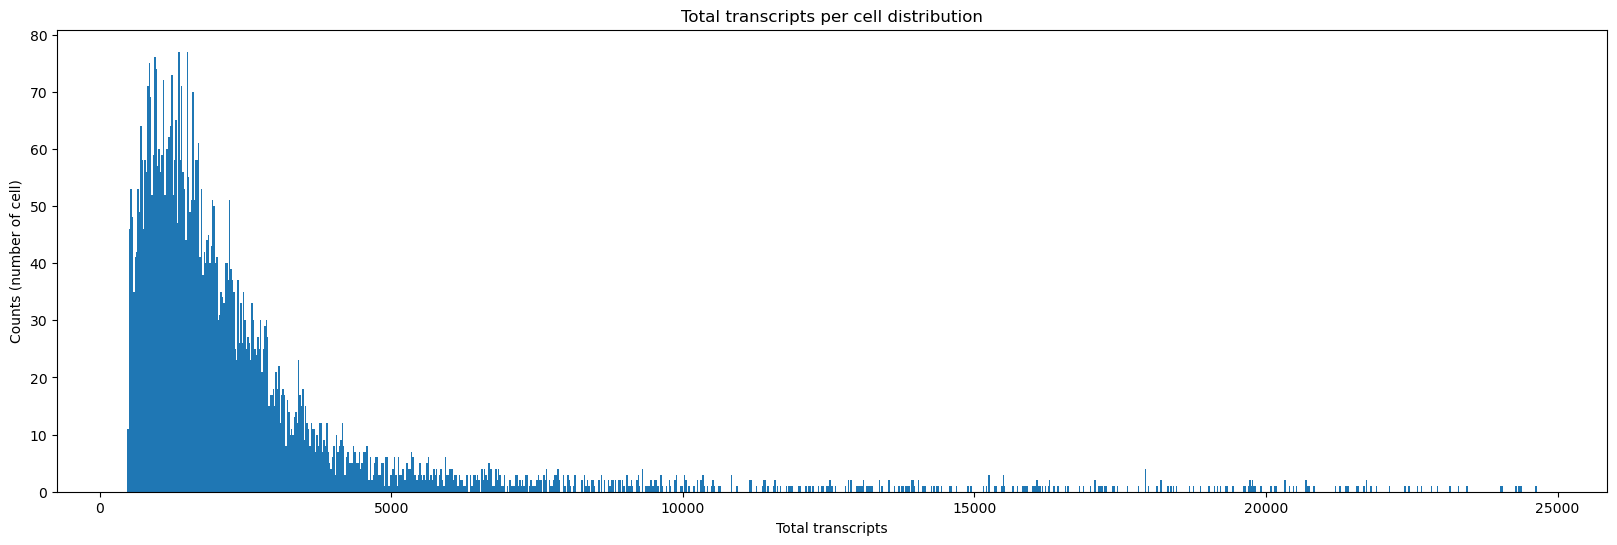

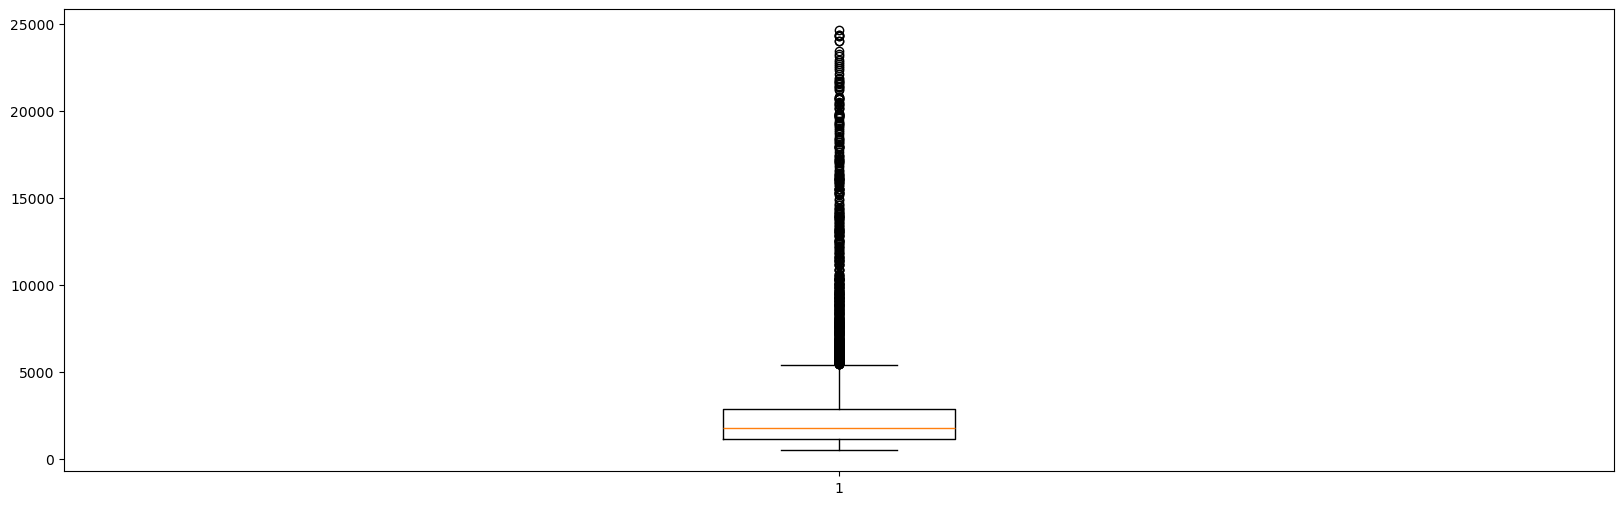

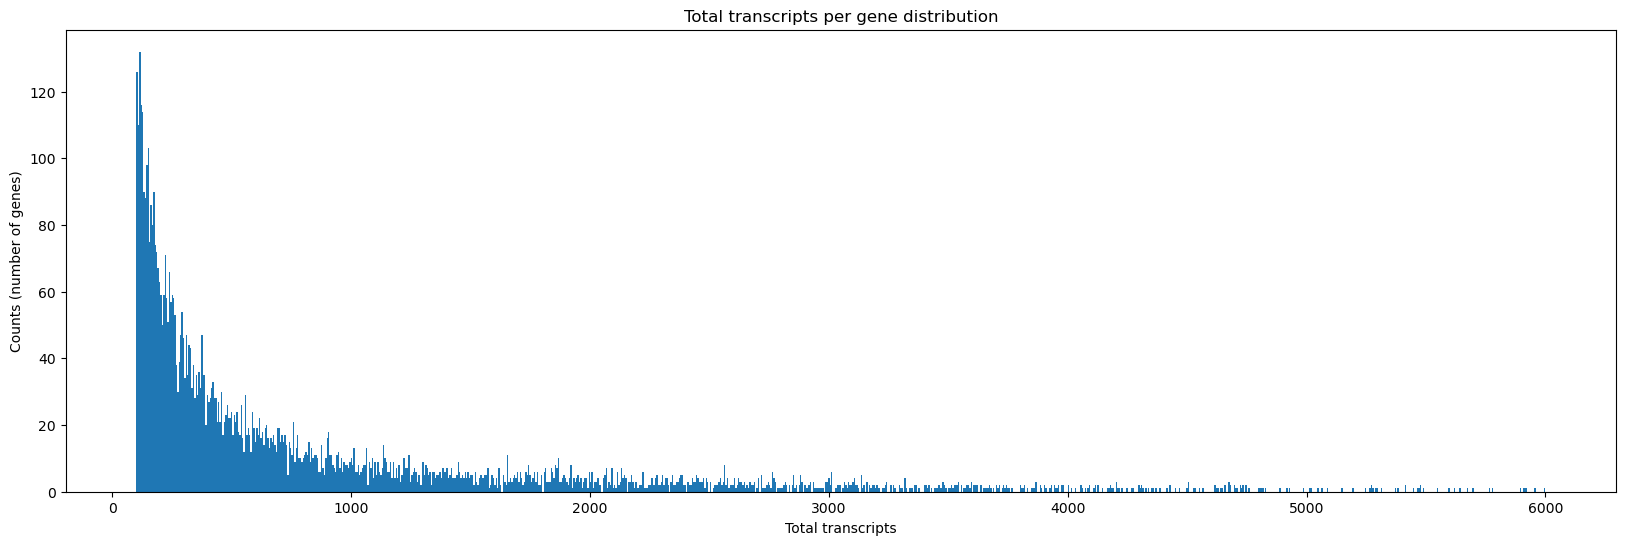

In [ ]:
plt.hist(total_counts,bins = 1000)
plt.title("Total transcripts per cell distribution")
plt.xlabel("Total transcripts")
plt.ylabel("Counts (number of cell)")
plt.show()
plt.hist(n_cells_by_counts,bins = 1000)
plt.title("Total transcripts per gene distribution")
plt.xlabel("Total transcripts")
plt.ylabel("Counts (number of genes)")
plt.show()


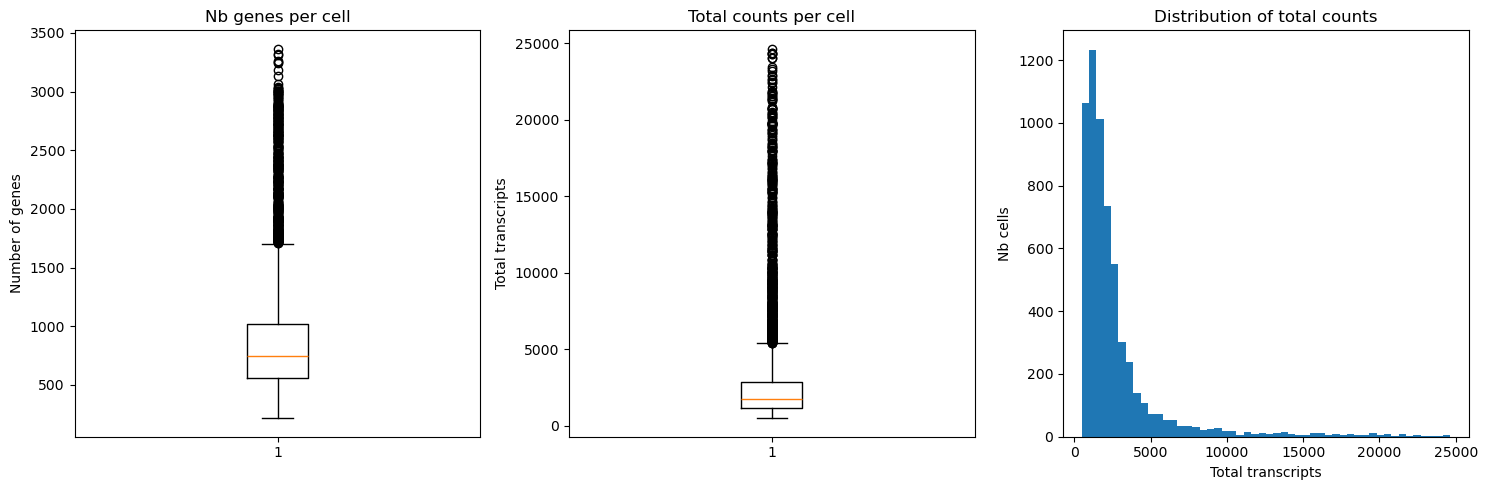

In [235]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Boxplot of nb genes expressed per cell
axes[0].boxplot(data.obs.n_genes_by_counts)
axes[0].set_title("Nb genes per cell")
axes[0].set_ylabel("Number of genes")

# 2. Boxplot of total counts (transcripts) per cell
axes[1].boxplot(data.obs.total_counts)
axes[1].set_title("Total counts per cell")
axes[1].set_ylabel("Total transcripts")

# 3. Histogram of total counts
axes[2].hist(data.obs.total_counts, bins=50)
axes[2].set_title("Distribution of total counts")
axes[2].set_xlabel("Total transcripts")
axes[2].set_ylabel("Nb cells")

plt.tight_layout()
plt.show()

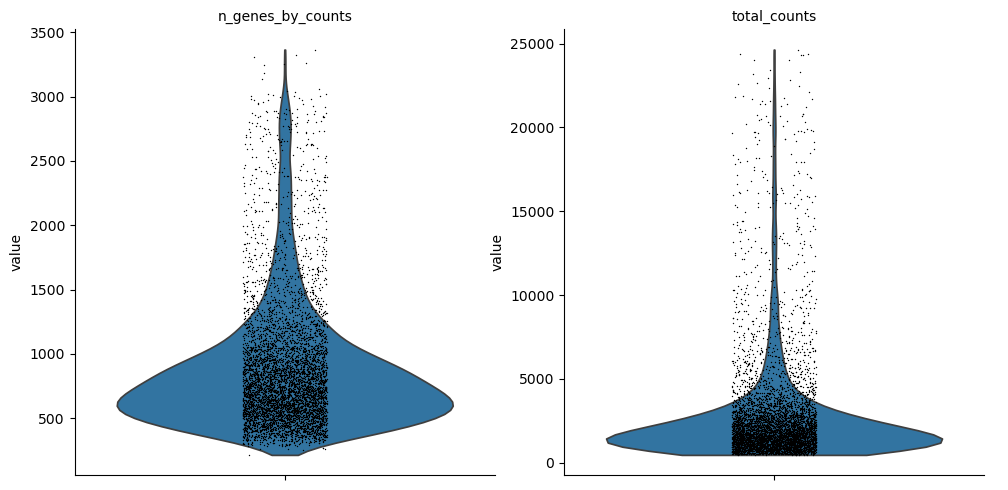

In [236]:
sc.pl.violin(data, ["n_genes_by_counts", "total_counts"], multi_panel=True)

In [195]:
#normalizing the data 
sc.pp.normalize_total(data,target_sum=10000)
sc.pp.log1p(data)

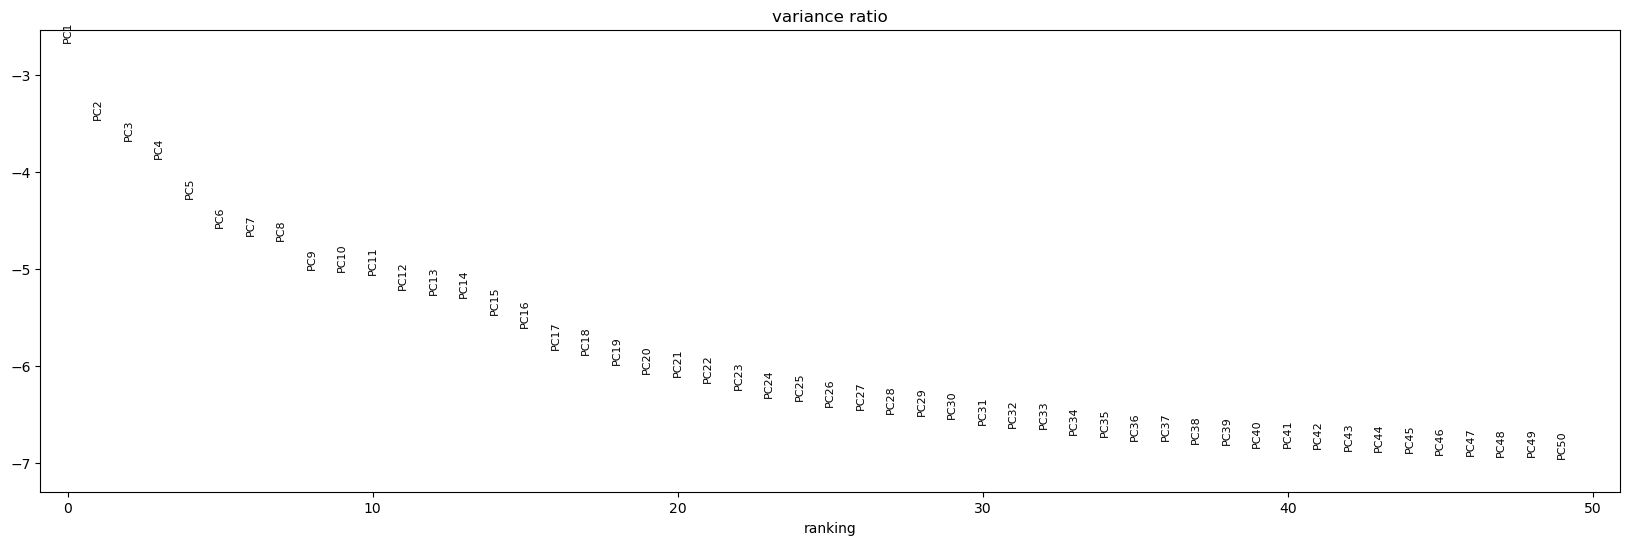

In [223]:
sc.tl.pca(data)
sc.pl.pca_variance_ratio(data, n_pcs=50, log=True)
sc.pp.neighbors(data, n_pcs=20)

In [224]:
sc.tl.leiden(data,resolution=0.05)

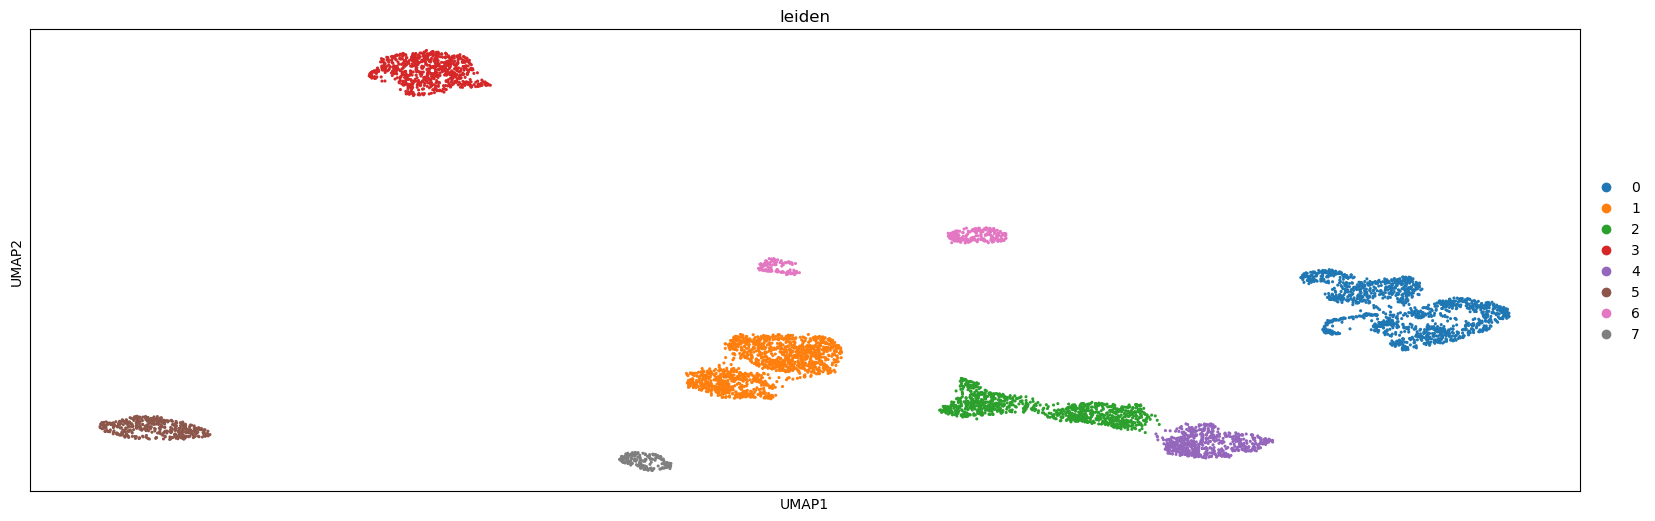

In [225]:
#t-sne
sc.tl.umap(data)
#visulisation
sc.pl.umap(data,color = "leiden")

In [249]:
sc.tl.rank_genes_groups(data, groupby="leiden",method = "wilcoxon",n_genes=3)

AttributeError: 'dict' object has no attribute 'size'

In [250]:
result = sc.get.rank_genes_groups_df(data,group = None)
clusters = result["group"].unique()
top_genes = []
for c in clusters:
    top_genes.append(result[result["group"] == c].sort_values(by = "logfoldchanges",ascending = False)["names"].iloc[0])

In [251]:
print(result)

   group        names     scores  logfoldchanges          pvals      pvals_adj
0      0        Trim9  40.113163        4.572017   0.000000e+00   0.000000e+00
1      0           Tg  39.516720        3.144830   0.000000e+00   0.000000e+00
2      0         klar  37.307339        1.831982  1.247895e-304  7.160648e-302
3      1       CG5065  50.287525        6.803074   0.000000e+00   0.000000e+00
4      1      CG32694  49.346573        5.568048   0.000000e+00   0.000000e+00
5      1          rut  48.762535        5.112083   0.000000e+00   0.000000e+00
6      2          ple  44.772537        6.720641   0.000000e+00   0.000000e+00
7      2         retn  42.190479        4.620941   0.000000e+00   0.000000e+00
8      2           to  40.522633        6.225798   0.000000e+00   0.000000e+00
9      3      CG34220  43.874237       12.099349   0.000000e+00   0.000000e+00
10     3      CG34324  43.817432       12.491337   0.000000e+00   0.000000e+00
11     3       Muc68D  43.760201       14.194219   0

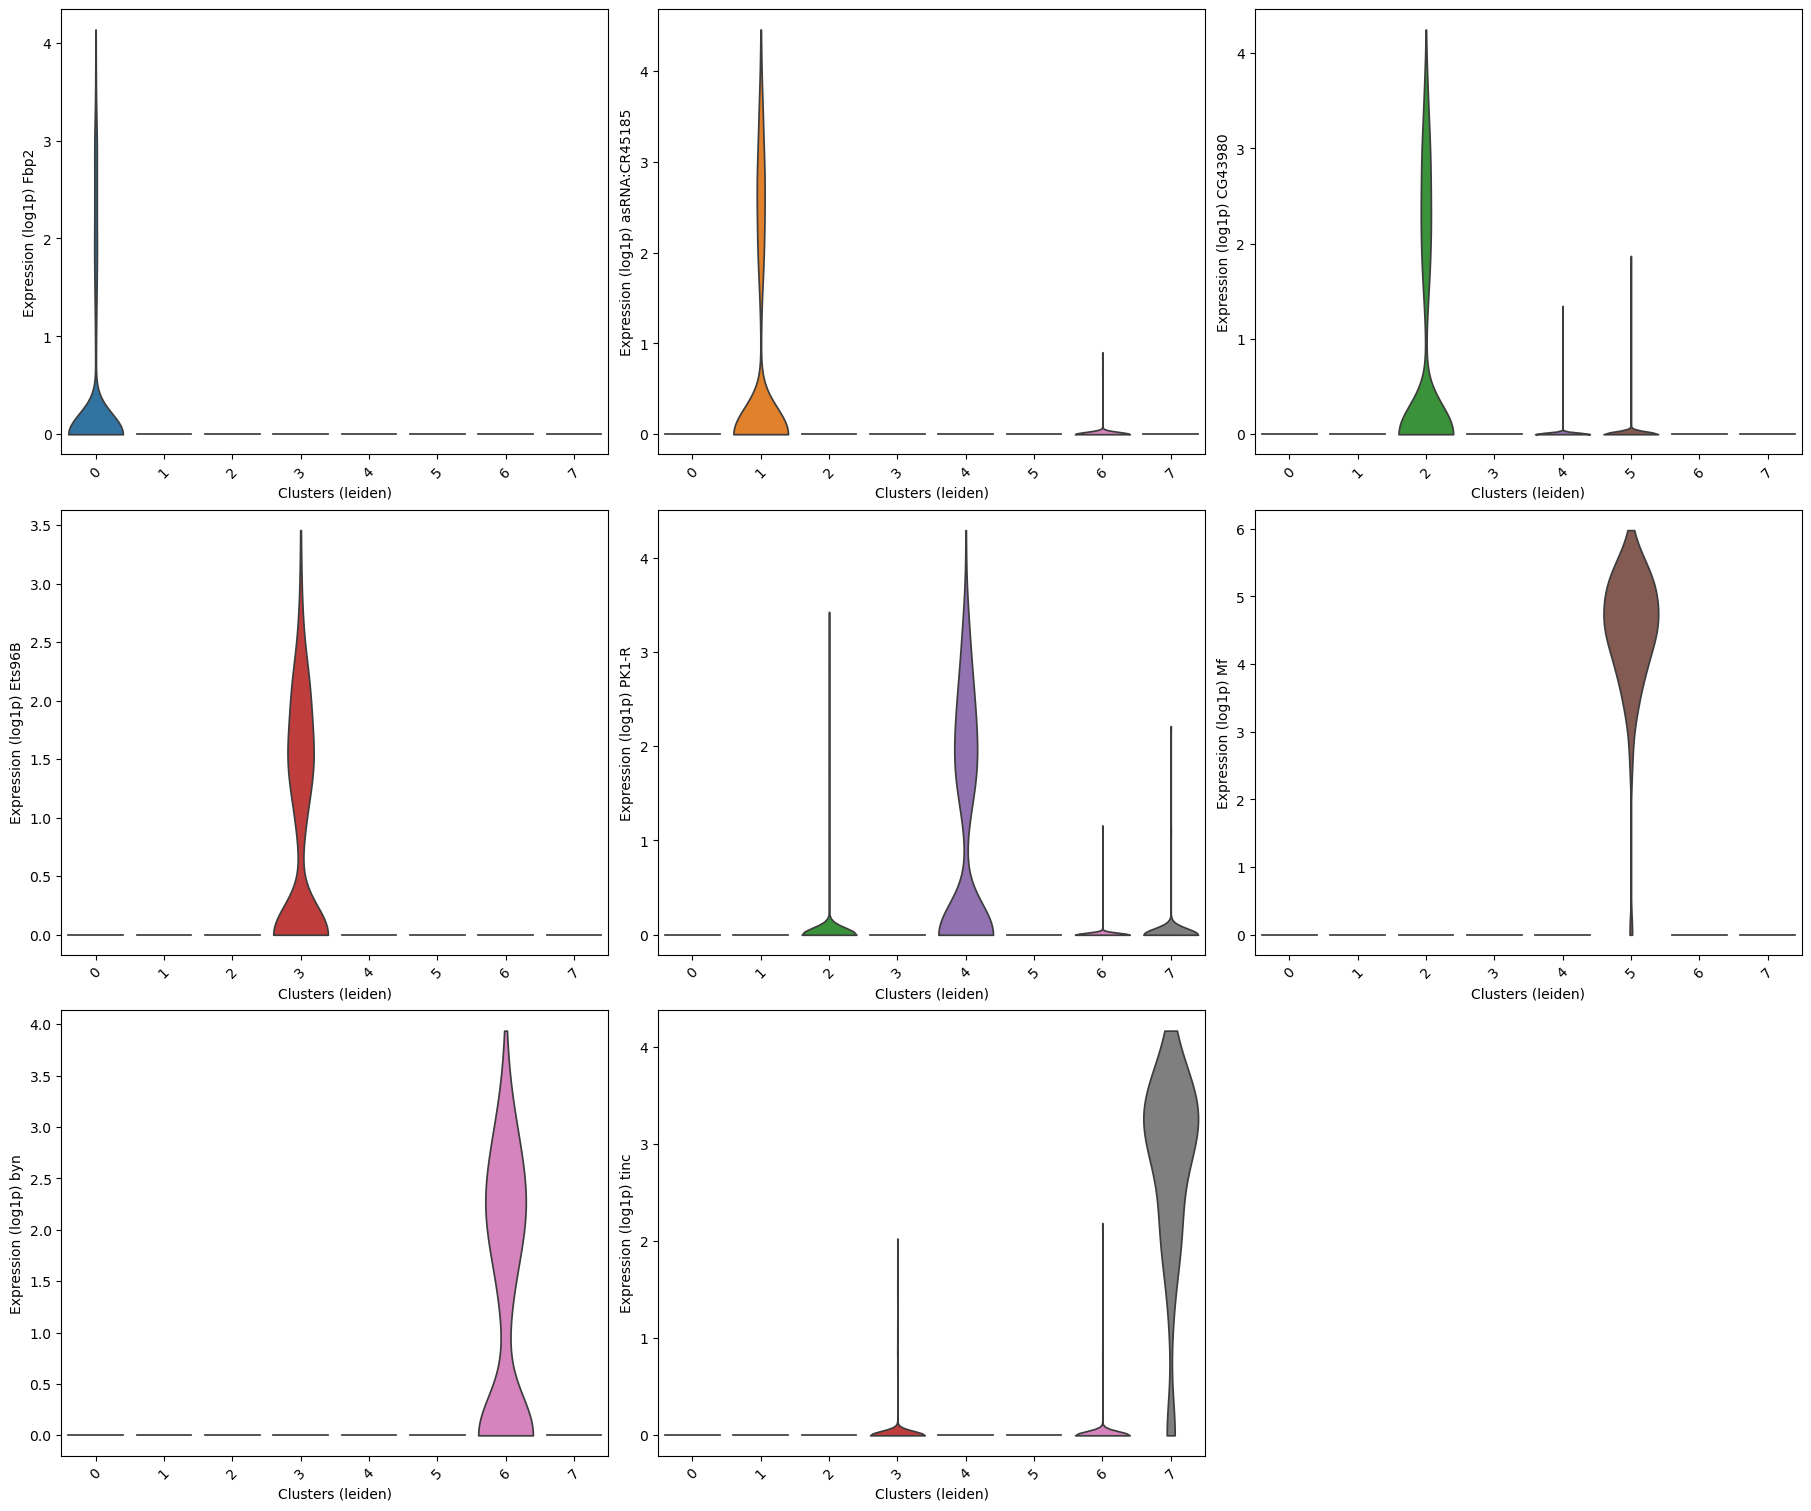

In [228]:
ncols = 3
nrows = (len(top_genes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows), constrained_layout=True)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, gene in enumerate(top_genes):
    sc.pl.violin(
        data,
        keys=gene,
        groupby="leiden",
        ax=axes[i],
        show=False,
        stripplot=False,
        rotation=45
    )
    axes[i].set_ylabel("Expression (log1p)" + " " +gene)
    axes[i].set_xlabel("Clusters (leiden)")

for j in range(len(top_genes), len(axes)):
    axes[j].axis("off")

plt.show()

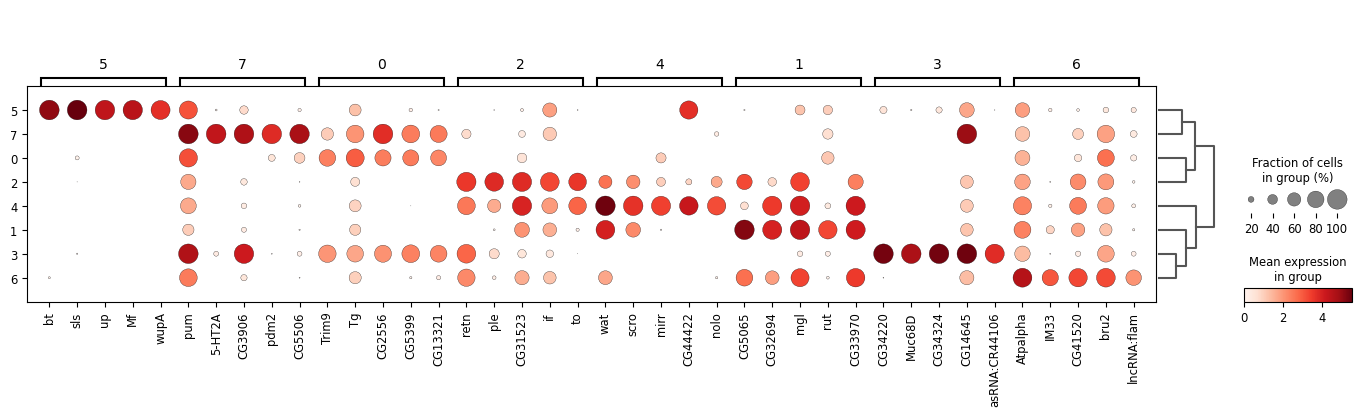

In [229]:
sc.pl.rank_genes_groups_dotplot(data, n_genes=5)

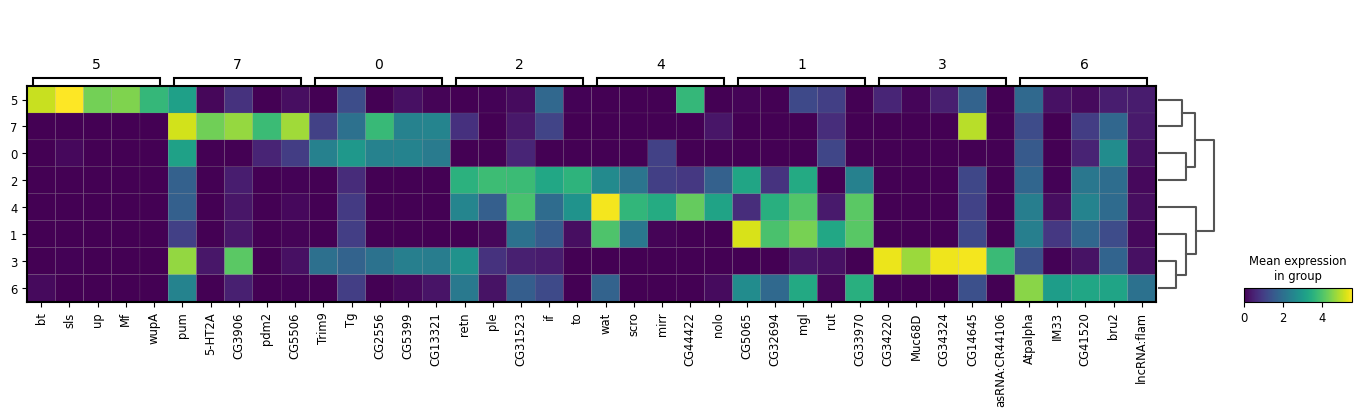

In [230]:
sc.pl.rank_genes_groups_matrixplot(data, n_genes=5)